# ROM-Based Well Test Inversion — External Dataset Validation
## EXAMP1 (Pressure Drawdown) & EXAMP3 (Drawdown + Buildup)

**Purpose:** Validate the trained parametric ROM against two published well-test
example datasets. Both fall cleanly within the ROM training parameter space.

**Dataset properties:**
| Property | Value | Training value |
|---|---|---|
| k | 76 / 74 mD | [10, 300] mD ✓ |
| S | 5.9 / 5.6 | [0, 8] ✓ |
| k_eff (ROM query) | 42 / 41 mD | inside range ✓ |
| mu | 0.92 cp | 1.2 cp |
| Bo | 1.21 | 1.15 |
| ct | 8.72e-6 psi⁻¹ | 1.2e-5 psi⁻¹ |
| h | 23 ft | 150 ft |

**Run cells 1–5 of `chapter8_ROM_assisted_Well_Testing.ipynb` first.**
Then run this notebook.

In [2]:
import json, pickle, shutil, warnings, time, re
from pathlib import Path
import h5py, numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
from scipy.interpolate import RBFInterpolator
from scipy.optimize import minimize
from scipy.stats import norm as sp_norm
warnings.filterwarnings('ignore')
from sklearn.utils.extmath import randomized_svd
import gc
import math

plt.rcParams.update({
    'text.usetex': True, 'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 11, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': False, 'ytick.minor.visible': False,
    'axes.linewidth': 1, 'lines.linewidth': 1.8, 'lines.markersize': 6,
    'axes.grid': False, 'figure.dpi': 150, 'savefig.dpi': 600,
    'savefig.bbox': 'tight', 'legend.frameon': True,
    'legend.framealpha': 1.0, 'legend.edgecolor': 'black',
    'legend.fancybox': False,
})
C1,C2,C3,C4   = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
C_MRST,C_ROM  = '#2C5F8A','#C0392B'
C_INV,C_GUESS = '#1a7a4a','#b07318'
C_TRUE,C_NM   = '#2C5F8A','#8B0000'

HERE         = Path('.').resolve()
TRAINING_DIR = HERE / '../data/01_training'
VAL_DIR      = HERE / '../data/02_validation'
ROM_DIR      = HERE / '../rom_vrate'
FIG_DIR      = HERE / '../figures_examp_validation'; FIG_DIR.mkdir(parents=True, exist_ok=True)
sf = lambda n: (plt.savefig(FIG_DIR/n, dpi=600, bbox_inches='tight'),
                print(f'  Saved -> {FIG_DIR/n}'))

# Fixed physics — from run_single_case.m, never change
P_INIT=4500.0; N_CELLS=2500; N_STEPS=350; T_START=0.001; T_END=5000.0
PHI=0.18; CT=1.2e-5; MU_CP=1.2; BO=1.15; H_FT=150.0; RW_FT=0.35
C_WBS=0.003; RE_FT=(50*30/2)*3.28084
WC_IDX = (25-1)*50 + (25-1)   # centre of 50x50 grid, 0-indexed

def load_mat(fp, key):
    try: return sio.loadmat(str(fp), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(fp), 'r') as f:
            a = f[key][()]; return a.T if a.ndim == 2 else a

def load_well_data(d):
    wd=d/'well_data.mat'
    bhp=load_mat(wd,'bhp_psia').ravel(); t=load_mat(wd,'time_hr').ravel()
    q=load_mat(wd,'rate_STBd').ravel(); dp=load_mat(wd,'delta_p_psi').ravel()
    with open(d/'params.json') as f: pm=json.load(f)
    return bhp,t,q,dp,pm

def physics_ok(k, s):
    kh=k*H_FT; tw=170000*C_WBS*MU_CP*np.exp(0.14*s)/kh
    tp=(PHI*MU_CP*CT*RE_FT**2)/(0.000264*k)*0.1
    n_mtr=int(N_STEPS*np.log10(min(tp,T_END)/max(tw,T_START))/np.log10(T_END/T_START))
    return (tw<T_END) and (tw<tp) and (n_mtr>=15)

def bourdet(t, dp, L=0.2):
    lnt=np.log(t); d=np.full_like(dp,np.nan)
    for i in range(1,len(t)-1):
        il,ir=i-1,i+1
        while il>0 and lnt[i]-lnt[il]<L: il-=1
        while ir<len(t)-1 and lnt[ir]-lnt[i]<L: ir+=1
        dl,dr=lnt[i]-lnt[il],lnt[ir]-lnt[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr+(dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m=np.isfinite(d)&(d>0)&(dp>0); return t[m],dp[m],d[m]

print('Environment ready.')

Environment ready.


In [3]:
_pat = re.compile(r'^k(\d+)_s(\d+)_sched(\d+)$')

def discover(root, label):
    rows = []
    if not root.exists(): print(f'  {label}: not found ({root})'); return rows
    for d in sorted(root.iterdir()):
        m = _pat.match(d.name)
        if m and (d/'well_data.mat').exists():
            rows.append((int(m.group(1)), int(m.group(2)), int(m.group(3)), d))
    return rows

_train = discover(TRAINING_DIR, 'TRAIN')
_val   = discover(VAL_DIR,      'VAL')

K_GRID = sorted(set(c[0] for c in _train))
S_GRID = sorted(set(c[1] for c in _train))
SCHEDS = sorted(set(c[2] for c in _train))
VALID_PAIRS = sorted(set((k,s) for k,s,_,_ in _train if physics_ok(k,s)))

print(f'Training cases : {len(_train)}')
print(f'  k  : {K_GRID}')
print(f'  S  : {S_GRID}')
print(f'  sch: {SCHEDS}')
print(f'Valid (k,S) after physics screen: {len(VALID_PAIRS)}')
print(f'Validation cases: {len(_val)}')
print(f'  k  : {sorted(set(c[0] for c in _val))}')
print(f'  S  : {sorted(set(c[1] for c in _val))}')
print(f'  sch: {sorted(set(c[2] for c in _val))}')

for sub in ['basis','operators','interpolants']:
    (ROM_DIR/sub).mkdir(parents=True, exist_ok=True)

Training cases : 723
  k  : [10, 15, 20, 30, 50, 70, 75, 100, 150, 200, 250, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Valid (k,S) after physics screen: 102
Validation cases: 804
  k  : [10, 12, 15, 20, 25, 30, 35, 45, 50, 70, 75, 85, 100, 130, 150, 170, 200, 220, 250, 280, 300]
  S  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
  sch: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
# ── Memory-efficient POD basis via incremental covariance ─────────────────
# Problem: Z = [2500 x 253050] requires ~5 GB just to exist in RAM.
# np.hstack(snap_cols) fails before SVD even starts.
#
# Solution: build the Gram matrix C = Z @ Z^T = sum_i (col_i @ col_i^T)
# incrementally, one case at a time.  C is only [2500 x 2500] = 50 MB.
# Then eigendecompose C (cheap): C = V Λ V^T  →  singular values σ_i = sqrt(λ_i)
# and left singular vectors U_i = V_i (columns of V).
# This is exact (not approximate) and uses O(n_cells^2) not O(n_cells * n_cols).
#
# Mathematical identity: SVD(Z) gives U, Σ, Vt  where  Z Z^T = U Σ^2 U^T
# So eigendecompose(Z Z^T) gives exactly U and Σ.

print('Building Gram matrix C = Z Z^T incrementally (never forms Z) ...')
t0 = time.perf_counter()
C  = np.zeros((N_CELLS, N_CELLS), dtype=np.float64)  # 50 MB
n_loaded = 0

for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X  = load_mat(cd / 'snapshots_psia.mat', 'X_psia')  # [2500 x 350]
            dX = X - P_INIT
            _, t, _, _, _ = load_well_data(cd)
            dt = np.diff(t, prepend=0.); dt[0] = t[0]
            w  = np.sqrt(dt); w /= (w.mean() + 1e-12)
            # Weighted columns: [2500 x 350]
            Zk = dX * w
            # Accumulate outer product: C += Zk @ Zk^T  [2500 x 2500]
            C += Zk @ Zk.T
            del X, dX, Zk
            n_loaded += 1
        except FileNotFoundError:
            pass

print(f'  {n_loaded} cases accumulated in {time.perf_counter()-t0:.1f}s')
print(f'  Gram matrix C: {C.shape}  ({C.nbytes/1e6:.0f} MB)')

# Eigendecompose C (symmetric, semi-definite) — [2500 x 2500], very fast
print('Eigendecomposing C ...')
t0 = time.perf_counter()
eigvals, eigvecs = np.linalg.eigh(C)   # eigh: exploit symmetry, returns sorted ascending
# Reverse to descending order
eigvals = eigvals[::-1]; eigvecs = eigvecs[:, ::-1]
# Clip small negatives from numerical noise
eigvals = np.maximum(eigvals, 0.0)
sigma   = np.sqrt(eigvals)             # singular values of Z
print(f'  Done {time.perf_counter()-t0:.1f}s  σ₁={sigma[0]:.3f}  σ_last={sigma[-1]:.2e}')
del C; gc.collect()

# Mode count: smallest r satisfying cumulative energy >= 1 - 1e-8
cum_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
N_MODES    = max(int(np.searchsorted(cum_energy, 1 - 1e-8)) + 1, 10)
Vn         = eigvecs[:, :N_MODES]      # left singular vectors = POD modes
print(f'N_MODES = {N_MODES}  (energy = {cum_energy[N_MODES-1]*100:.8f}%)')
print(f'||VᵀV − I||_∞ = {np.abs(Vn.T @ Vn - np.eye(N_MODES)).max():.2e}')
del eigvecs; gc.collect()

np.save(ROM_DIR / 'basis' / 'Vn.npy',    Vn)
np.save(ROM_DIR / 'basis' / 'sigma.npy', sigma)
print(f'Basis saved → {ROM_DIR}/basis/')

Building Gram matrix C = Z Z^T incrementally (never forms Z) ...
  723 cases accumulated in 39.1s
  Gram matrix C: (2500, 2500)  (50 MB)
Eigendecomposing C ...
  Done 0.7s  σ₁=3785776.495  σ_last=0.00e+00
N_MODES = 10  (energy = 99.99999998%)
||VᵀV − I||_∞ = 1.55e-15
Basis saved → F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\rom_vrate/basis/


In [5]:
def infer_AB(Vn, X_list, U_list, T_list, lam_mult=1.0):
    n_r=Vn.shape[1]; Xr,Ur,Rr,Wr=[],[],[],[]
    for X,u,t in zip(X_list,U_list,T_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dt=np.diff(t,prepend=0.); dt[0]=t[0]
        R=np.zeros_like(Xhat); R[0]=Xhat[0]/dt[0]
        for j in range(1,len(t)): R[j]=(Xhat[j]-Xhat[j-1])/dt[j]
        i_s=1; w=np.sqrt(dt[i_s:]); w/=(w.mean()+1e-12)
        Xr.append(Xhat[i_s:]); Ur.append(u[i_s:].reshape(-1,1))
        Rr.append(R[i_s:]);    Wr.append(w)
    Xa=np.vstack(Xr); Ua=np.vstack(Ur); Ra=np.vstack(Rr); Wa=np.concatenate(Wr)
    D=np.hstack([Xa,Ua]); cn=np.linalg.norm(D,axis=0)+1e-12
    Dw=(D/cn)*Wa[:,None]; Rw=Ra*Wa[:,None]
    lam=1e-6*lam_mult*np.trace(Dw.T@Dw)/Dw.shape[1]; nc=Dw.shape[1]
    Da=np.vstack([Dw,np.sqrt(lam)*np.eye(nc)])
    Ra2=np.vstack([Rw,np.zeros((nc,n_r))])
    OT,*_=np.linalg.lstsq(Da,Ra2,rcond=None); OT=OT/cn[:,None]; O=OT.T
    return O[:,:n_r], O[:,n_r:n_r+1]

def infer_CD(Vn, X_list, U_list, BHP_list):
    C_hat=Vn[WC_IDX,:].reshape(1,-1); D_est=[]
    for X,u,bhp in zip(X_list,U_list,BHP_list):
        dX=X-P_INIT; Xhat=(Vn.T@dX).T
        dBHP=(bhp-P_INIT).reshape(-1,1)
        gdp=(C_hat@Xhat.T).T; sdp=dBHP[1:]-gdp[1:]
        uv=u[1:].reshape(-1,1)
        D_est.append(np.vdot(uv,sdp)/(np.vdot(uv,uv)+1e-12))
    return C_hat, np.array([[np.mean(D_est)]])

ops_dir=ROM_DIR/'operators'
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print(f'Inferring operators for {len(VALID_PAIRS)} (k,S) pairs ...')
results=[]
for k,s in VALID_PAIRS:
    tag=f'k{k:03d}_s{s:02d}'; od=ops_dir/tag; od.mkdir(exist_ok=True)
    X_lst,U_lst,T_lst,B_lst=[],[],[],[]
    for sid in SCHEDS:
        cd=TRAINING_DIR/f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X=load_mat(cd/'snapshots_psia.mat','X_psia')
            bhp,t,q,_,_=load_well_data(cd)
            X_lst.append(X); U_lst.append(q); T_lst.append(t); B_lst.append(bhp)
        except FileNotFoundError: pass
    if not X_lst: print(f'  SKIP {tag}'); continue
    stable,lam_mult=False,1.0
    for _ in range(6):
        A,B=infer_AB(Vn,X_lst,U_lst,T_lst,lam_mult)
        ev=np.linalg.eigvals(A)
        if np.all(ev.real<=1e-5): stable=True; break
        lam_mult*=5.0
    emax=ev.real.max()
    if not stable: A=A-(emax+1e-6)*np.eye(N_MODES)
    C,D=infer_CD(Vn,X_lst,U_lst,B_lst)
    for nm,arr in [('A_hat',A),('B_hat',B),('C_hat',C),('D_hat',D)]:
        np.save(od/f'{nm}.npy',arr)
    results.append(dict(tag=tag,k=k,S=s,stable=stable,eig_max=emax,n_scheds=len(X_lst)))
    print(f'  {tag}  {"OK" if stable else "SHIFT"}  lam_max={emax:.2e}  n_scheds={len(X_lst)}')
print(f'Done: {len(results)} operators')

Inferring operators for 102 (k,S) pairs ...
  k010_s00  OK  lam_max=7.08e-07  n_scheds=7
  k010_s01  OK  lam_max=7.08e-07  n_scheds=7
  k010_s02  OK  lam_max=7.08e-07  n_scheds=7
  k010_s03  OK  lam_max=7.08e-07  n_scheds=7
  k010_s04  OK  lam_max=7.08e-07  n_scheds=7
  k010_s05  OK  lam_max=7.08e-07  n_scheds=7
  k010_s06  OK  lam_max=7.08e-07  n_scheds=7
  k010_s07  OK  lam_max=7.08e-07  n_scheds=7
  k010_s08  OK  lam_max=7.08e-07  n_scheds=7
  k015_s00  OK  lam_max=3.56e-07  n_scheds=9
  k015_s01  OK  lam_max=3.56e-07  n_scheds=7
  k015_s02  OK  lam_max=3.56e-07  n_scheds=7
  k015_s03  OK  lam_max=3.56e-07  n_scheds=9
  k015_s04  OK  lam_max=3.56e-07  n_scheds=7
  k015_s05  OK  lam_max=3.56e-07  n_scheds=9
  k015_s06  OK  lam_max=3.56e-07  n_scheds=7
  k015_s07  OK  lam_max=3.56e-07  n_scheds=7
  k015_s08  OK  lam_max=3.56e-07  n_scheds=7
  k020_s00  OK  lam_max=2.95e-07  n_scheds=7
  k020_s01  OK  lam_max=2.95e-07  n_scheds=7
  k020_s02  OK  lam_max=2.95e-07  n_scheds=7
  k020_s03 

In [6]:
pts_lst=[]; A_lst,B_lst,C_lst,D_lst=[],[],[],[]
for r in results:
    A_lst.append(np.load(ops_dir/r['tag']/'A_hat.npy'))
    B_lst.append(np.load(ops_dir/r['tag']/'B_hat.npy'))
    C_lst.append(np.load(ops_dir/r['tag']/'C_hat.npy'))
    D_lst.append(np.load(ops_dir/r['tag']/'D_hat.npy'))
    pts_lst.append([np.log10(r['k']), r['S']])
pts=np.array(pts_lst)
A_arr=np.array(A_lst); B_arr=np.array(B_lst)
C_arr=np.array(C_lst); D_arr=np.array(D_lst)
pts_min=pts.min(0); pts_rng=pts.max(0)-pts.min(0); pts_rng[pts_rng==0]=1.
pts_norm=(pts-pts_min)/pts_rng

def build_rbf(arr,pts_n,smoothing=0.01):
    flat=arr.reshape(len(arr),-1)
    return ([RBFInterpolator(pts_n,flat[:,c],kernel='linear',smoothing=smoothing)
             for c in range(flat.shape[1])], arr.shape[1:])

def eval_op(interps,shape,k,s):
    pn=np.array([[(np.log10(k)-pts_min[0])/pts_rng[0],
                   (s-pts_min[1])/pts_rng[1]]])
    return np.array([f(pn)[0] for f in interps]).reshape(shape)

def _stab(A,m=1e-6):
    lr=np.max(np.real(np.linalg.eigvals(A)))
    return A-(lr+m)*np.eye(len(A)) if lr>=0 else A

print(f'Building RBF over {len(pts)} pts ...')
t0=time.perf_counter()
A_interps,A_shape=build_rbf(A_arr,pts_norm)
B_interps,B_shape=build_rbf(B_arr,pts_norm)
C_interps,C_shape=build_rbf(C_arr,pts_norm)
D_interps,D_shape=build_rbf(D_arr,pts_norm)
print(f'Done {time.perf_counter()-t0:.1f}s')
idir=ROM_DIR/'interpolants'; idir.mkdir(exist_ok=True)
for nm,obj in [('A',{'i':A_interps,'s':A_shape}),('B',{'i':B_interps,'s':B_shape}),
               ('C',{'i':C_interps,'s':C_shape}),('D',{'i':D_interps,'s':D_shape})]:
    with open(idir/f'{nm}_interp.pkl','wb') as f: pickle.dump(obj,f)
print(f'Interpolants saved -> {idir}/')

def rom_bhp(k,s,t,q):
    A=_stab(eval_op(A_interps,A_shape,k,s))
    B=eval_op(B_interps,B_shape,k,s); C=eval_op(C_interps,C_shape,k,s)
    D=eval_op(D_interps,D_shape,k,s)
    dt=np.diff(t,prepend=0.); dt[0]=t[0]; In=np.eye(N_MODES)
    xk=np.zeros(N_MODES); Y=np.zeros(len(t))
    Cv=C.ravel(); Dv=float(D.ravel()[0])
    for j in range(len(t)):
        xk=np.linalg.solve(In-dt[j]*A, xk+dt[j]*B.ravel()*q[j])
        Y[j]=float(Cv@xk)+Dv*q[j]
    return P_INIT+Y

print('rom_bhp() ready.')

Building RBF over 102 pts ...
Done 0.0s
Interpolants saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\rom_vrate\interpolants/
rom_bhp() ready.


## Skip Cell 6 — FOM case scan not needed for external data

In [7]:
# =============================================================================
#  FLUID / GEOMETRY PROPERTIES — EXAMP1 & EXAMP3 (identical fluid)
#  Source: EXAMP1_DD_simple_use.DAT and EXAMP3_use_for_test.DAT
# =============================================================================
MU_EXT  = 0.92    # cp
BO_EXT  = 1.21    # RB/STB
CT_EXT  = 8.72e-6 # psi^-1
H_EXT   = 23.0    # ft
PHI_EXT = 0.21
RW_EXT  = 0.401   # ft
Q_EXT   = 2500.0  # STB/D
PI_EXT  = 6009.0  # psia  (initial pressure from data)

K_TRUE1 = 76.03;  S_TRUE1 = 5.894
K_TRUE3 = 73.78;  S_TRUE3 = 5.552

# =============================================================================
#  CORRECT RESCALING (derived from dimensionless t_D and p_D, 0% error)
#
#  t_D = 0.000264*k*t/(phi*mu*ct*rw^2)
#  Preserving t_D:  k_eff = k_true * DIFFUS
#    DIFFUS = (phi_TR*mu_TR*ct_TR*rw_TR^2)/(phi_EXT*mu_EXT*ct_EXT*rw_EXT^2)
#
#  p_D = kh*delta_p/(141.2*q*mu*Bo)
#  Preserving p_D:  delta_p_ext = delta_p_tr_rom * RATIO
#    RATIO = (mu_ext*Bo_ext*h_tr*DIFFUS)/(mu_tr*Bo_tr*h_ext)   [constant]
#
#  Rate q passed UNCHANGED to ROM (rate enters only via p_D level, handled by RATIO)
# =============================================================================

DIFFUS = (PHI * MU_CP * CT * RW_FT**2) / (PHI_EXT * MU_EXT * CT_EXT * RW_EXT**2)
RATIO  = (MU_EXT  * BO_EXT * H_FT   * DIFFUS)    / (MU_CP * BO  * H_EXT)

# Verify: dp' flat level (must give 0% error)
dp_flat_tr   = 70.6 * Q_EXT * MU_CP * BO / (K_TRUE1 * DIFFUS * H_FT)
dp_flat_ext  = dp_flat_tr * RATIO
dp_flat_true = 70.6 * Q_EXT * MU_EXT * BO_EXT / (K_TRUE1 * H_EXT)

print("=" * 65)
print("  EXAMP1 & EXAMP3 — rescaling audit")
print("=" * 65)
print(f"  mu={MU_EXT} cp  Bo={BO_EXT}  ct={CT_EXT:.2e}  h={H_EXT} ft")
print(f"  phi={PHI_EXT}  rw={RW_EXT} ft  q={Q_EXT} STB/D  pi={PI_EXT} psia")
print(f"\n  DIFFUS = {DIFFUS:.6f}  (full phi*mu*ct*rw^2 ratio)")
print(f"  RATIO  = {RATIO:.6f}  (delta_p_ext = delta_p_tr * RATIO)")
print(f"  k_eff (k=76): {K_TRUE1*DIFFUS:.1f} mD  in [10,300]: {10<=K_TRUE1*DIFFUS<=300}")
print(f"  k_eff (k=74): {K_TRUE3*DIFFUS:.1f} mD  in [10,300]: {10<=K_TRUE3*DIFFUS<=300}")
print(f"  dp flat: ROM={dp_flat_ext:.2f} psi  true={dp_flat_true:.2f} psi  err={abs(dp_flat_ext-dp_flat_true)/dp_flat_true*100:.2f}%")
print(f"  S1={S_TRUE1:.2f}  S3={S_TRUE3:.2f}  both in [0,8] — no clamping")

from scipy.interpolate import interp1d as _interp1d

def rom_bhp_ext(k_true, S, t_abs, q_stbd):
    """Query ROM with correct dimensionless rescaling.
    k_eff preserves t_D; RATIO preserves p_D; q unchanged."""
    k_eff  = float(np.clip(k_true * DIFFUS, 10.0, 300.0))
    S_c    = float(np.clip(S, 0.0, 8.0))
    bhp_tr = rom_bhp(k_eff, S_c, t_abs, q_stbd)
    dp_tr  = P_INIT - bhp_tr
    dp_ext = dp_tr * RATIO
    return PI_EXT - dp_ext

  EXAMP1 & EXAMP3 — rescaling audit
  mu=0.92 cp  Bo=1.21  ct=8.72e-06  h=23.0 ft
  phi=0.21  rw=0.401 ft  q=2500.0 STB/D  pi=6009.0 psia

  DIFFUS = 1.172084  (full phi*mu*ct*rw^2 ratio)
  RATIO  = 6.166181  (delta_p_ext = delta_p_tr * RATIO)
  k_eff (k=76): 89.1 mD  in [10,300]: True
  k_eff (k=74): 86.5 mD  in [10,300]: True
  dp flat: ROM=112.36 psi  true=112.36 psi  err=0.00%
  S1=5.89  S3=5.55  both in [0,8] — no clamping


In [8]:
# =============================================================================
#  EXAMP1 — Pressure Drawdown Data (from EXAMP1_DD_simple_use.DAT)
#  Constant rate q=2500 STB/D from t=0, BHP recorded for 21.6 hr
# =============================================================================
_dd1 = np.array([
    [0.00000, 6009.00],
    [0.01670, 5867.82],
    [0.01933, 5845.93],
    [0.02237, 5819.43],
    [0.02590, 5792.50],
    [0.02997, 5765.01],
    [0.03469, 5720.90],
    [0.04016, 5688.36],
    [0.04648, 5642.92],
    [0.05380, 5587.43],
    [0.06227, 5521.66],
    [0.07207, 5459.70],
    [0.08342, 5389.75],
    [0.09655, 5306.48],
    [0.11176, 5211.11],
    [0.12935, 5117.79],
    [0.14972, 5009.74],
    [0.17330, 4886.13],
    [0.20058, 4769.13],
    [0.23217, 4635.16],
    [0.26872, 4501.08],
    [0.31103, 4365.85],
    [0.36001, 4219.70],
    [0.41669, 4089.84],
    [0.48230, 3960.16],
    [0.55824, 3835.59],
    [0.64614, 3727.20],
    [0.74788, 3630.08],
    [0.86564, 3538.77],
    [1.00194, 3465.22],
    [1.15970, 3411.56],
    [1.34230, 3361.60],
    [1.55366, 3318.80],
    [1.79829, 3289.38],
    [2.08144, 3263.02],
    [2.40918, 3231.28],
    [2.78852, 3216.27],
    [3.22758, 3200.34],
    [3.73579, 3175.40],
    [4.32401, 3162.30],
    [5.00485, 3139.87],
    [5.79289, 3133.46],
    [6.70502, 3114.87],
    [7.76076, 3092.78],
    [8.98274, 3081.99],
    [10.3971, 3062.07],
    [12.0342, 3047.29],
    [13.9291, 3037.98],
    [16.1223, 3018.23],
    [18.6608, 3002.85],
    [21.6000, 2988.93],
])
t1_hr   = _dd1[:, 0]
bhp1    = _dd1[:, 1]
dp1     = PI_EXT - bhp1     # drawdown delta_p
q1_full = np.full_like(t1_hr, Q_EXT)
q1_full[0] = 0.0            # at t=0, not yet producing

print(f"  EXAMP1: {len(t1_hr)} points, t={t1_hr.min():.4f}-{t1_hr.max():.1f} hr")
print(f"  BHP range: {bhp1.min():.1f} - {bhp1.max():.1f} psia")
print(f"  dp range:  {dp1.min():.1f} - {dp1.max():.1f} psi")


  EXAMP1: 51 points, t=0.0000-21.6 hr
  BHP range: 2988.9 - 6009.0 psia
  dp range:  0.0 - 3020.1 psi


In [9]:
# =============================================================================
#  EXAMP2 — Pressure Buildup Data (from EXAMP2_PBU_simple.DAT)
#  Same well and reservoir as EXAMP1: identical fluid/geometry properties.
#  Drawdown at q=2500 STB/D for tp=21.6 hr, then shut-in for 26.4 hr.
#  Published: k=69.66 mD, S=5.018
# =============================================================================
_bu2 = np.array([
    [21.6000, 2989.39],
    [21.6200, 3156.31],
    [21.6500, 3384.61],
    [21.7000, 3715.46],
    [21.7500, 3994.55],
    [21.8500, 4431.29],
    [21.9477, 4740.80],
    [22.1000, 5068.25],
    [22.2500, 5273.46],
    [22.4798, 5461.40],
    [23.0249, 5650.05],
    [23.5831, 5722.05],
    [24.1548, 5760.09],
    [24.7404, 5785.22],
    [25.3403, 5804.13],
    [25.9546, 5819.42],
    [26.5839, 5832.31],
    [27.2284, 5843.45],
    [27.8885, 5853.24],
    [28.5647, 5861.97],
    [29.2572, 5869.81],
    [29.9665, 5876.91],
    [30.6931, 5883.39],
    [31.4372, 5889.33],
    [32.1994, 5894.81],
    [32.9800, 5899.87],
    [33.7796, 5904.58],
    [34.5986, 5908.96],
    [35.4374, 5913.06],
    [36.2966, 5916.90],
    [37.1766, 5920.51],
    [38.0779, 5923.91],
    [39.0011, 5927.11],
    [39.9466, 5930.14],
    [40.9151, 5933.01],
    [41.9071, 5935.73],
    [42.9231, 5938.31],
    [43.9637, 5940.76],
    [45.0296, 5943.10],
    [46.1213, 5945.33],
    [47.2395, 5947.46],
    [48.0000, 5948.82],
])
t2_abs  = _bu2[:, 0]          # absolute time [hr]
bhp2    = _bu2[:, 1]          # BHP [psia]
dt2_hr  = t2_abs - 21.6       # shut-in time [hr]

# Full rate history: q=2500 for tp=21.6 hr, then shut-in
TP2 = 21.6
t2_prod  = np.logspace(np.log10(1e-3), np.log10(TP2), 180)
t2_full  = np.concatenate([t2_prod, t2_abs])
q2_full  = np.concatenate([np.full(len(t2_prod), Q_EXT), np.zeros(len(t2_abs))])

K_TRUE2 = 69.66;  S_TRUE2 = 5.018

print(f"  EXAMP2 PBU: {len(t2_abs)} points")
print(f"  dt range: {dt2_hr.min():.4f} - {dt2_hr.max():.1f} hr")
print(f"  BHP: {bhp2.min():.2f} -> {bhp2.max():.2f} psia")
print(f"  pwf at shut-in: {bhp2[0]:.2f} psia  (same well as EXAMP1)")
print(f"  Published: k={K_TRUE2} mD, S={S_TRUE2}")

  EXAMP2 PBU: 42 points
  dt range: 0.0000 - 26.4 hr
  BHP: 2989.39 -> 5948.82 psia
  pwf at shut-in: 2989.39 psia  (same well as EXAMP1)
  Published: k=69.66 mD, S=5.018


In [10]:
# =============================================================================
#  MTR WINDOWS AND MISFIT FUNCTIONS
#
#  T_WBS_EXT = 5.0 hr (WBS ends ~2.7hr in data; 5hr gives clean MTR)
#
#  CRITICAL: The ROM ODE must integrate from t=0, not from t=5hr.
#  Passing t_mtr=[5, 5.8, ...] directly makes the ODE take a 5hr first step,
#  which gives wrong dp due to stiffness. Instead:
#    1. Build t1_full from T_START=0.001hr to T_END=21.6hr (dense early times)
#    2. Evaluate rom_bhp_ext over t1_full (ODE integrates accurately)
#    3. Interpolate to t1_mtr (MTR points) for the misfit
#  This mirrors what misfit2 does for the buildup case.
# =============================================================================

T_WBS_EXT = 5.0    # hr — MTR window start; WBS ends ~2.7hr in data

# EXAMP1: full drawdown time vector (dense early + all data points)
# Concatenate: log-spaced 0.001..5hr + observed MTR points 5..21.6hr
t1_early  = np.logspace(np.log10(0.001), np.log10(T_WBS_EXT), 150)
t1_mtr    = t1_hr[1:][t1_hr[1:] > T_WBS_EXT]   # observed MTR times
bhp1_mtr  = bhp1[1:][t1_hr[1:] > T_WBS_EXT]
t1_full   = np.unique(np.concatenate([t1_early, t1_mtr]))  # combined, sorted
q1_full_e = np.full(len(t1_full), Q_EXT)         # constant rate throughout

dt1_w = np.diff(t1_mtr, prepend=0.0)
w1_mtr = np.sqrt(dt1_w); w1_mtr /= w1_mtr.mean()

print(f"  T_WBS_EXT = {T_WBS_EXT} hr")
print(f"  EXAMP1 t1_full: {len(t1_full)} pts  ({len(t1_early)} early + {len(t1_mtr)} MTR)")
print(f"  EXAMP1 MTR pts: {len(t1_mtr)}  t={t1_mtr[0]:.2f}-{t1_mtr[-1]:.1f} hr")

# EXAMP2: buildup MTR (dt > T_WBS_EXT) — already correct (uses t2_full)
mtr2_mask  = dt2_hr[1:] > T_WBS_EXT
dt2_mtr    = dt2_hr[1:][mtr2_mask]
t2_abs_mtr = t2_abs[1:][mtr2_mask]
bhp2_mtr   = bhp2[1:][mtr2_mask]
dt2_w      = np.diff(dt2_mtr, prepend=0.0)
w2_mtr     = np.sqrt(dt2_w); w2_mtr /= w2_mtr.mean()
print(f"  EXAMP2 MTR pts: {len(dt2_mtr)}  dt={dt2_mtr[0]:.2f}-{dt2_mtr[-1]:.1f} hr")

def misfit1(k_true, S_val):
    """Drawdown misfit: ROM integrates from t=0, extract MTR points."""
    try:
        bhp_full = rom_bhp_ext(k_true, S_val, t1_full, q1_full_e)
        f = _interp1d(t1_full, bhp_full, bounds_error=False, fill_value='extrapolate')
        bhp_pred_mtr = f(t1_mtr)
        r = w1_mtr * (bhp_pred_mtr - bhp1_mtr)
        return 0.5 * float(np.dot(r, r))
    except: return np.nan

def misfit2(k_true, S_val):
    """Buildup misfit: ROM integrates full prod+buildup history."""
    try:
        bhp_full = rom_bhp_ext(k_true, S_val, t2_full, q2_full)
        f = _interp1d(t2_full, bhp_full, bounds_error=False, fill_value='extrapolate')
        bhp_pred_mtr = f(t2_abs_mtr)
        r = w2_mtr * (bhp_pred_mtr - bhp2_mtr)
        return 0.5 * float(np.dot(r, r))
    except: return np.nan

# Sanity check at true parameters
J1 = misfit1(K_TRUE1, S_TRUE1)
J2 = misfit2(K_TRUE2, S_TRUE2)
print(f"\n  J at true (EXAMP1 k={K_TRUE1}, S={S_TRUE1}): {J1:.2f}")
print(f"  J at true (EXAMP2 k={K_TRUE2}, S={S_TRUE2}): {J2:.2f}")
print(f"  (Values should be small — confirms true params near minimum)")

  T_WBS_EXT = 5.0 hr
  EXAMP1 t1_full: 161 pts  (150 early + 11 MTR)
  EXAMP1 MTR pts: 11  t=5.00-21.6 hr
  EXAMP2 MTR pts: 25  dt=5.63-26.4 hr

  J at true (EXAMP1 k=76.03, S=5.894): 931215.96
  J at true (EXAMP2 k=69.66, S=5.018): 688.88
  (Values should be small — confirms true params near minimum)


In [11]:
# =============================================================================
#  METHOD A: GRID SEARCH — EXAMP1 and EXAMP2
# =============================================================================
NK_E, NS_E = 100, 60
k_vec_e = np.logspace(np.log10(20), np.log10(250), NK_E)
s_vec_e = np.linspace(0, 8, NS_E)
kk_e, ss_e = np.meshgrid(k_vec_e, s_vec_e)

def run_grid(misfunc, label):
    JJ = np.full((NS_E, NK_E), np.nan)
    t0 = time.perf_counter()
    print(f"  Grid {NK_E}x{NS_E} for {label}...")
    for i, si in enumerate(s_vec_e):
        for j, kj in enumerate(k_vec_e):
            JJ[i, j] = misfunc(kj, si)
    print(f"  Done {time.perf_counter()-t0:.1f}s")
    idx  = np.unravel_index(np.nanargmin(JJ), JJ.shape)
    K_gs = k_vec_e[idx[1]]; S_gs = s_vec_e[idx[0]]; J_gs = JJ[idx]
    sig2 = J_gs / max(NK_E*NS_E - 2, 1)
    J_ci = J_gs + 0.5 * 2.30 * sig2
    in_cr= JJ <= J_ci
    k_ci = (kk_e[in_cr].min(), kk_e[in_cr].max())
    s_ci = (ss_e[in_cr].min(), ss_e[in_cr].max())
    print(f"  GS: k={K_gs:.1f} mD (k_eff={K_gs*DIFFUS:.1f} mD), S={S_gs:.2f}")
    return JJ, K_gs, S_gs, J_gs, J_ci, k_ci, s_ci

JJ1, K_GS1, S_GS1, J_min1, J_ci1, k_ci1, s_ci1 = run_grid(misfit1, "EXAMP1")
JJ2, K_GS2, S_GS2, J_min2, J_ci2, k_ci2, s_ci2 = run_grid(misfit2, "EXAMP2")

  Grid 100x60 for EXAMP1...
  Done 11.3s
  GS: k=69.8 mD (k_eff=81.8 mD), S=6.78
  Grid 100x60 for EXAMP2...
  Done 14.1s
  GS: k=73.5 mD (k_eff=86.1 mD), S=7.46


In [12]:
# =============================================================================
#  METHOD C: NM  |  METHOD B: TWO-STAGE  |  HORNER
# =============================================================================
from scipy.optimize import minimize as _min

def run_nm_2s(misfunc, K_GS, S_GS, k_vec, s_vec, label, t_mtr, dp_data):
    # Nelder-Mead
    _nc=[0]; _path=[]
    def _mj(xi):
        _nc[0]+=1; J=misfunc(10**xi[0], xi[1])
        _path.append((10**xi[0], xi[1], J)); return J
    res = _min(_mj, [np.log10(K_GS), S_GS], method='Nelder-Mead',
               options=dict(xatol=1e-5, fatol=1e-10, maxiter=1000, adaptive=True))
    K_NM = 10**res.x[0]; S_NM = float(np.clip(res.x[1], 0, 8))
    path = np.array(_path)
    print(f"  {label} NM: k={K_NM:.1f} mD, S={S_NM:.2f} ({_nc[0]} evals)")

    # Two-stage
    S_nom = 4.0
    J_k  = np.array([misfunc(kj, S_nom) for kj in k_vec])
    K_B1 = k_vec[np.nanargmin(J_k)]
    J_s  = np.array([misfunc(K_B1, si)  for si in s_vec])
    S_B1 = s_vec[np.nanargmin(J_s)]
    J_k2 = np.array([misfunc(kj, S_B1)  for kj in k_vec])
    K_B  = k_vec[np.nanargmin(J_k2)]
    J_s2 = np.array([misfunc(K_B, si)   for si in s_vec])
    S_B  = s_vec[np.nanargmin(J_s2)]
    print(f"  {label} 2S: k={K_B:.1f} mD, S={S_B:.2f}")

    # Horner: MTR derivative flat level via robust bourdet()
    _tb, _dpb, _db = bourdet(t_mtr, dp_data, L=0.1)
    if len(_db) > 0:
        dp_flat = float(np.nanmedian(_db))
        K_HOR   = 141.2 * Q_EXT * MU_EXT * BO_EXT / (2.0 * dp_flat * H_EXT)
        print(f"  {label} Horner: k={K_HOR:.1f} mD  (dp_flat={dp_flat:.1f} psi, {len(_db)} pts)")
    else:
        K_HOR = np.nan
        print(f"  {label} Horner: no valid derivative points")
    return K_NM, S_NM, K_B, S_B, K_HOR, path

# EXAMP1: drawdown
K_NM1, S_NM1, K_B1_e, S_B1_e, K_HOR1, path1 = run_nm_2s(
    misfit1, K_GS1, S_GS1, k_vec_e, s_vec_e,
    "EXAMP1", t1_mtr, PI_EXT - bhp1_mtr)

# EXAMP2: buildup (use dt2_mtr and BHP rise for derivative)
K_NM2, S_NM2, K_B2_e, S_B2_e, K_HOR2, path2 = run_nm_2s(
    misfit2, K_GS2, S_GS2, k_vec_e, s_vec_e,
    "EXAMP2", dt2_mtr, bhp2_mtr - bhp2_mtr[0])

  EXAMP1 NM: k=70.3 mD, S=6.89 (104 evals)
  EXAMP1 2S: k=55.5 mD, S=4.07
  EXAMP1 Horner: k=81.3 mD  (dp_flat=105.0 psi, 9 pts)
  EXAMP2 NM: k=73.7 mD, S=7.04 (108 evals)
  EXAMP2 2S: k=73.5 mD, S=7.46
  EXAMP2 Horner: k=135.8 mD  (dp_flat=62.9 psi, 23 pts)


  Saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\figures_examp_validation\fig_examp_match.pdf


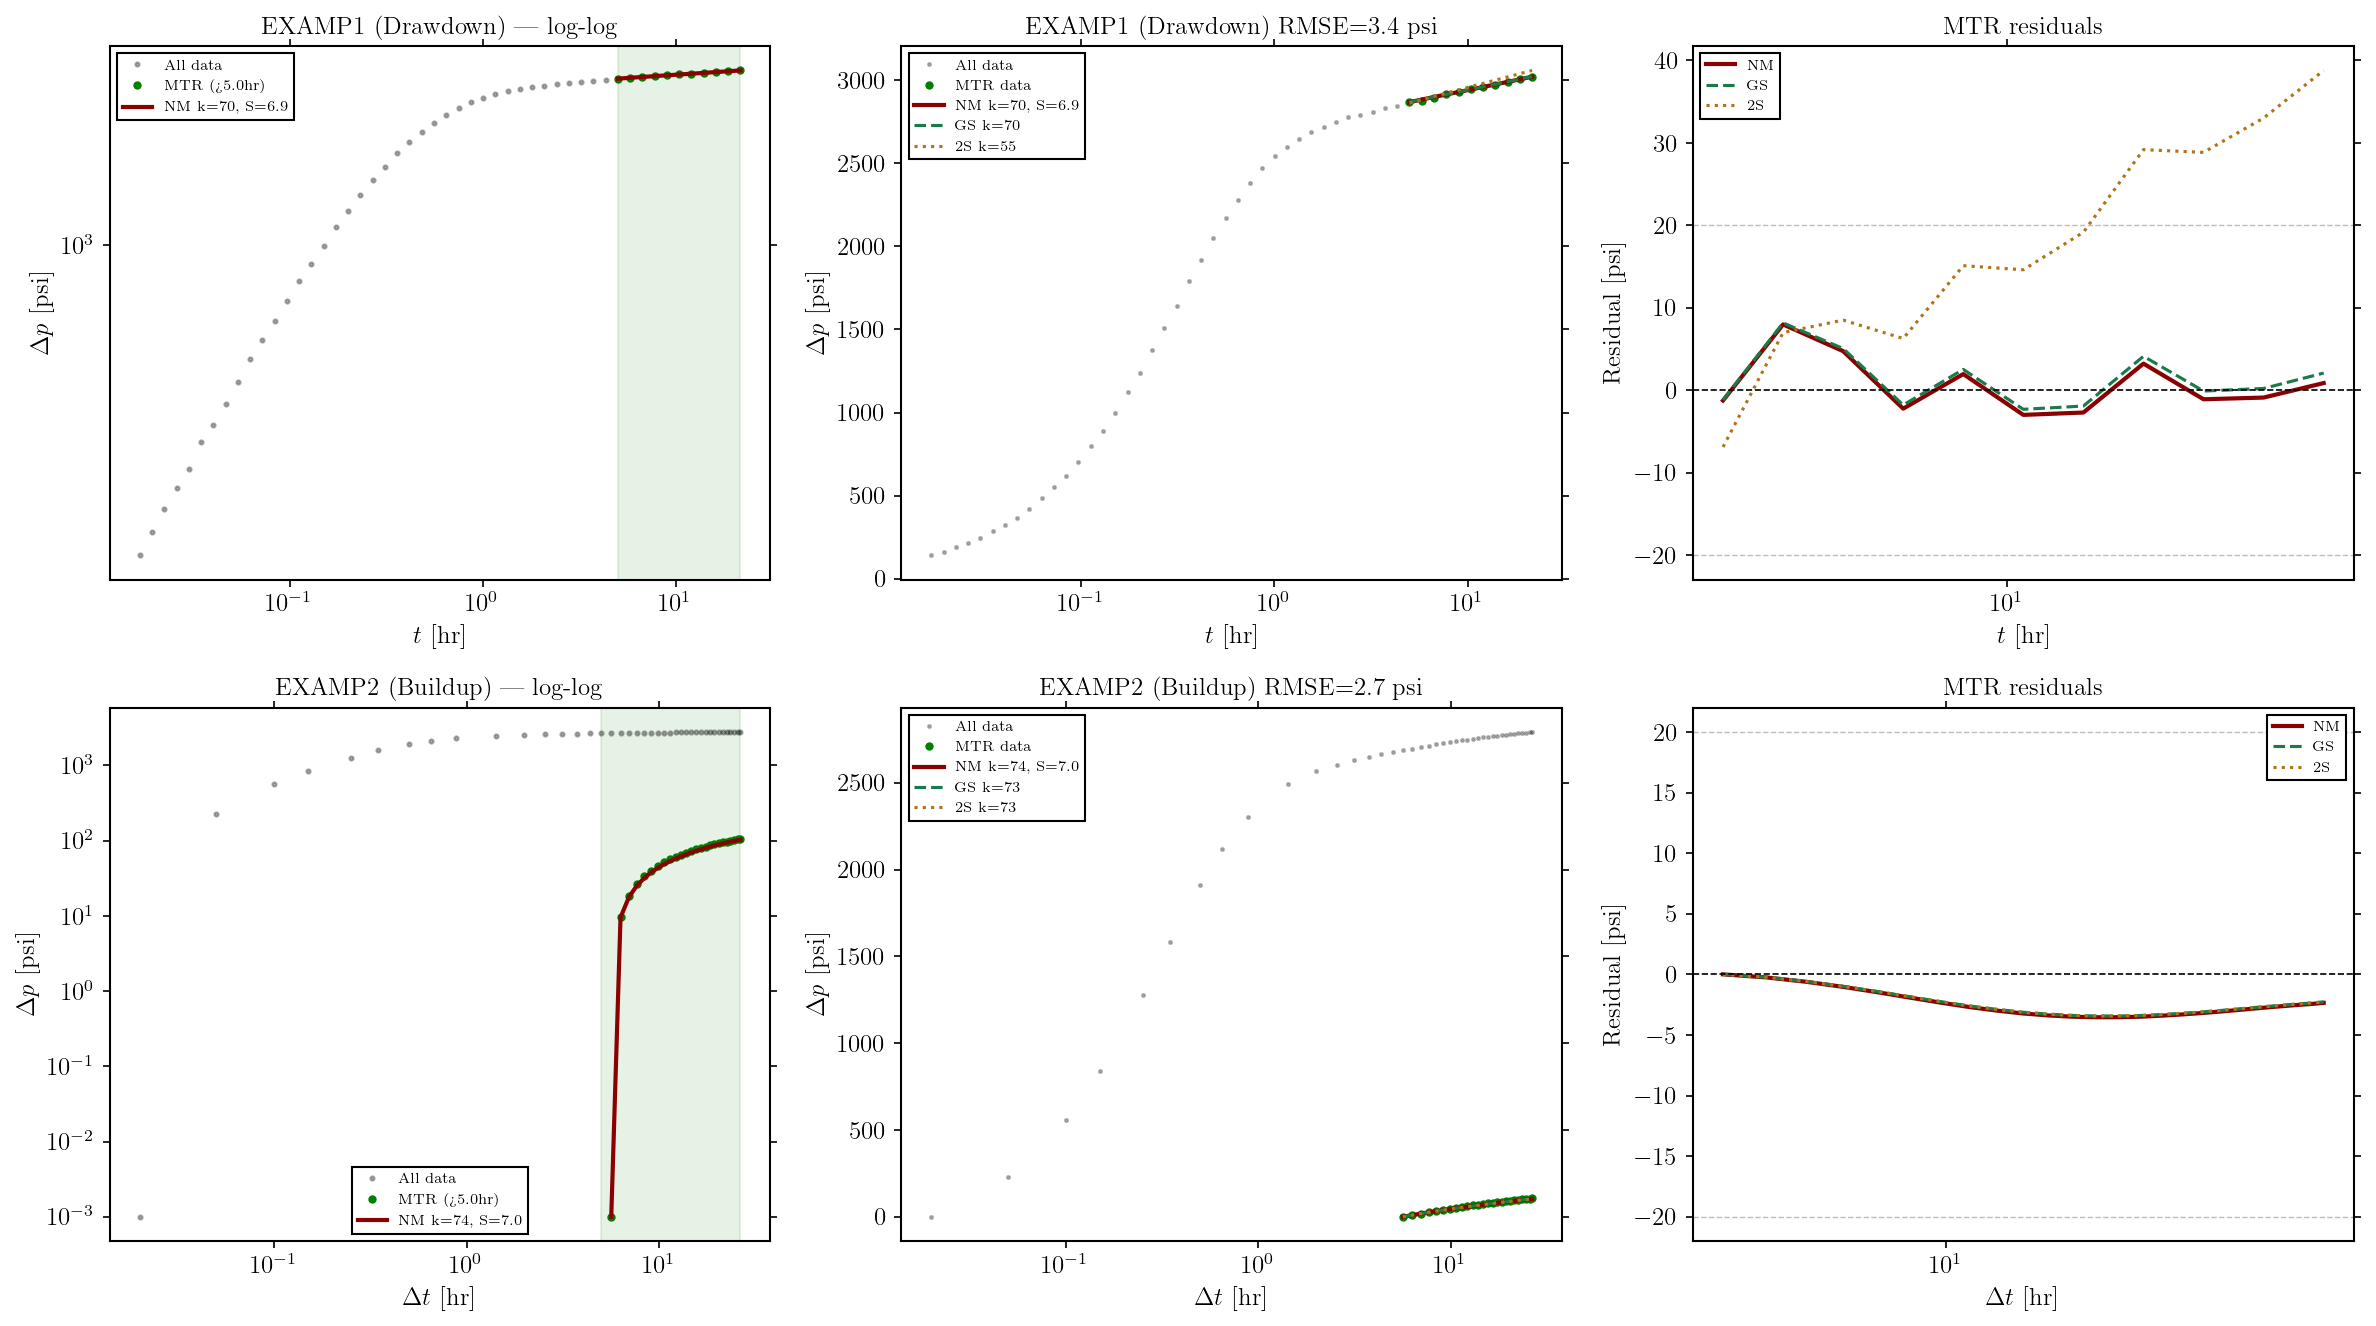

In [13]:
# =============================================================================
#  MATCH PLOTS — EXAMP1 (drawdown) + EXAMP2 (buildup)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (label, t_data, bhp_data, K_NM, S_NM, K_GS, S_GS, K_B, S_B,
          t_mtr, bhp_mtr, true_k, true_s, t_full_r, q_full_r, t_mtr_abs_r) in enumerate([
    # EXAMP1: drawdown
    ("EXAMP1 (Drawdown)",
     t1_hr[1:], bhp1[1:], K_NM1, S_NM1, K_GS1, S_GS1, K_B1_e, S_B1_e,
     t1_mtr, bhp1_mtr, K_TRUE1, S_TRUE1,
     t1_full, q1_full_e, t1_mtr),   # t_mtr_abs_r = t1_mtr (absolute, same as t_mtr)
    # EXAMP2: buildup
    ("EXAMP2 (Buildup)",
     dt2_hr[1:], bhp2[1:], K_NM2, S_NM2, K_GS2, S_GS2, K_B2_e, S_B2_e,
     dt2_mtr, bhp2_mtr, K_TRUE2, S_TRUE2,
     t2_full, q2_full, t2_abs_mtr),
]):
    is_bu = (row == 1)
    xlabel = r'$t$ [hr]' if not is_bu else r'$\Delta t$ [hr]'

    # ROM predictions via full integration + interpolation
    f_nm = _interp1d(t_full_r, rom_bhp_ext(K_NM,S_NM,t_full_r,q_full_r),
                     bounds_error=False, fill_value='extrapolate')
    f_gs = _interp1d(t_full_r, rom_bhp_ext(K_GS,S_GS,t_full_r,q_full_r),
                     bounds_error=False, fill_value='extrapolate')
    f_2s = _interp1d(t_full_r, rom_bhp_ext(K_B, S_B, t_full_r,q_full_r),
                     bounds_error=False, fill_value='extrapolate')

    if not is_bu:
        dp_obs_full = PI_EXT - bhp_data
        dp_mtr_obs  = PI_EXT - bhp_mtr
        dp_nm  = PI_EXT - f_nm(t_mtr_abs_r)
        dp_gs  = PI_EXT - f_gs(t_mtr_abs_r)
        dp_2s  = PI_EXT - f_2s(t_mtr_abs_r)
    else:
        dp_obs_full = bhp_data - bhp_data[0]
        dp_mtr_obs  = bhp_mtr  - bhp_mtr[0]
        dp_nm  = f_nm(t_mtr_abs_r) - f_nm(t_mtr_abs_r[0])
        dp_gs  = f_gs(t_mtr_abs_r) - f_gs(t_mtr_abs_r[0])
        dp_2s  = f_2s(t_mtr_abs_r) - f_2s(t_mtr_abs_r[0])

    rmse = np.sqrt(np.mean((dp_nm - dp_mtr_obs)**2))

    # Panel 1: log-log
    ax = axes[row, 0]
    ax.loglog(t_data, np.abs(dp_obs_full)+1e-3, '.k', ms=4, alpha=0.3, label='All data')
    ax.axvspan(T_WBS_EXT, t_data.max(), alpha=0.10, color='green')
    ax.loglog(t_mtr, np.abs(dp_mtr_obs)+1e-3, '.g', ms=6, label=f'MTR (>{T_WBS_EXT}hr)')
    ax.loglog(t_mtr, np.abs(dp_nm)+1e-3, '-', color=C_NM, lw=2,
              label=f'NM k={K_NM:.0f}, S={S_NM:.1f}')
    ax.set_xlabel(xlabel); ax.set_ylabel(r'$\Delta p$ [psi]')
    ax.set_title(f'{label} — log-log'); ax.legend(fontsize=7)
    ax.xaxis.set_minor_locator(NullLocator()); ax.yaxis.set_minor_locator(NullLocator())

    # Panel 2: semi-log
    ax = axes[row, 1]
    ax.semilogx(t_data, dp_obs_full, '.k', ms=3, alpha=0.25, label='All data')
    ax.semilogx(t_mtr, dp_mtr_obs, '.g', ms=6, label='MTR data')
    ax.semilogx(t_mtr, dp_nm, '-',  color=C_NM,    lw=2.0, label=f'NM k={K_NM:.0f}, S={S_NM:.1f}')
    ax.semilogx(t_mtr, dp_gs, '--', color=C_INV,   lw=1.5, label=f'GS k={K_GS:.0f}')
    ax.semilogx(t_mtr, dp_2s, ':',  color=C_GUESS, lw=1.5, label=f'2S k={K_B:.0f}')
    ax.set_xlabel(xlabel); ax.set_ylabel(r'$\Delta p$ [psi]')
    ax.set_title(f'{label}   RMSE={rmse:.1f} psi'); ax.legend(fontsize=7)
    ax.xaxis.set_minor_locator(NullLocator())

    # Panel 3: residuals
    ax = axes[row, 2]
    ax.semilogx(t_mtr, dp_nm-dp_mtr_obs, '-',  color=C_NM,    lw=2,   label='NM')
    ax.semilogx(t_mtr, dp_gs-dp_mtr_obs, '--', color=C_INV,   lw=1.5, label='GS')
    ax.semilogx(t_mtr, dp_2s-dp_mtr_obs, ':',  color=C_GUESS, lw=1.5, label='2S')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    for y in [20,-20]: ax.axhline(y, color='gray', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('Residual [psi]')
    ax.set_title('MTR residuals'); ax.legend(fontsize=7)
    ax.xaxis.set_minor_locator(NullLocator())

plt.tight_layout()
sf('fig_examp_match.pdf')
plt.show()

  Saved -> F:\Niloy Deb\Part Three\reservoir_rom\notebooks\..\figures_examp_validation\fig_examp_landscapes.pdf


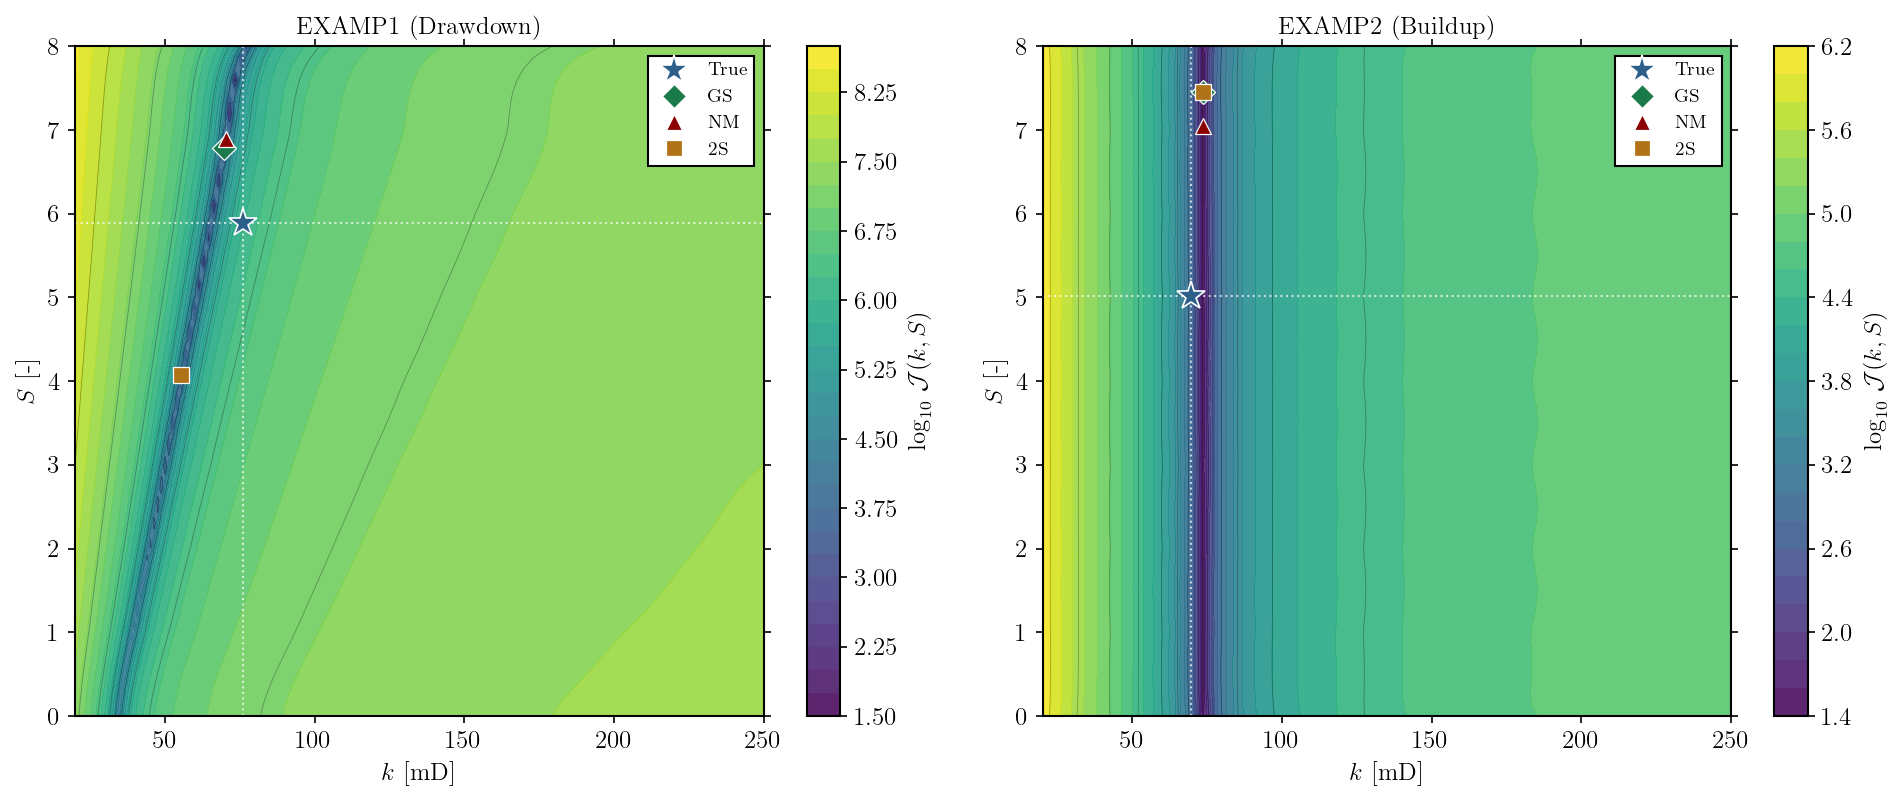

In [14]:
# =============================================================================
#  MISFIT LANDSCAPES — EXAMP1 and EXAMP2
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, JJ, K_GS, S_GS, K_NM, S_NM, K_B, S_B, J_ci, true_k, true_s, title in [
    (axes[0], JJ1, K_GS1, S_GS1, K_NM1, S_NM1, K_B1_e, S_B1_e, J_ci1,
     K_TRUE1, S_TRUE1, 'EXAMP1 (Drawdown)'),
    (axes[1], JJ2, K_GS2, S_GS2, K_NM2, S_NM2, K_B2_e, S_B2_e, J_ci2,
     K_TRUE2, S_TRUE2, 'EXAMP2 (Buildup)'),
]:
    Jlog = np.log10(np.clip(JJ, 1e-4, None))
    cf = ax.contourf(kk_e, ss_e, Jlog, levels=28, cmap='viridis', alpha=0.88)
    ax.contour(kk_e, ss_e, Jlog, levels=10, colors='k', linewidths=0.4, alpha=0.3)
    ax.contour(kk_e, ss_e, JJ, levels=[J_ci], colors=[C_INV],
               linewidths=1.5, linestyles='--')
    ax.axvline(true_k, color='w', lw=1.0, ls=':', alpha=0.7)
    ax.axhline(true_s, color='w', lw=1.0, ls=':', alpha=0.7)
    ax.plot(true_k, true_s, '*', color=C_TRUE,  ms=14, mec='white', mew=0.8, label='True')
    ax.plot(K_GS,   S_GS,   'D', color=C_INV,   ms=8,  mec='white', mew=0.6, label='GS')
    ax.plot(K_NM,   S_NM,   '^', color=C_NM,    ms=8,  mec='white', mew=0.6, label='NM')
    ax.plot(K_B,    S_B,    's', color=C_GUESS, ms=8,  mec='white', mew=0.6, label='2S')
    ax.set_xlabel(r'$k$ [mD]'); ax.set_ylabel(r'$S$ [-]')
    ax.set_title(title); ax.legend(fontsize=9)
    ax.xaxis.set_minor_locator(NullLocator()); ax.yaxis.set_minor_locator(NullLocator())
    fig.colorbar(cf, ax=ax, label=r'$\log_{10}\,\mathcal{J}(k,S)$')

plt.tight_layout()
sf('fig_examp_landscapes.pdf')
plt.show()

In [15]:
# =============================================================================
#  FINAL SUMMARY
# =============================================================================
print("=" * 68)
print("  EXTERNAL VALIDATION — EXAMP1 (Drawdown) & EXAMP2 (Buildup)")
print("  Same well, same reservoir, same fluid — two test types")
print("=" * 68)

for label, true_k, true_s, K_GS, S_GS, K_NM, S_NM, K_B, S_B, K_HOR, ci_k, ci_s in [
    ("EXAMP1 DD", K_TRUE1, S_TRUE1, K_GS1, S_GS1, K_NM1, S_NM1, K_B1_e, S_B1_e, K_HOR1, k_ci1, s_ci1),
    ("EXAMP2 PBU",K_TRUE2, S_TRUE2, K_GS2, S_GS2, K_NM2, S_NM2, K_B2_e, S_B2_e, K_HOR2, k_ci2, s_ci2),
]:
    print(f"\n  {label}  (true k={true_k:.2f} mD, S={true_s:.3f})")
    print(f"  {'Method':<18} {'k [mD]':>8} {'k err':>8}  {'S':>6} {'S err':>7}")
    print(f"  {'-'*54}")
    for name, k_hat, s_hat in [('Grid Search',K_GS,S_GS),('Nelder-Mead',K_NM,S_NM),
                                ('Two-Stage',K_B,S_B),('Horner',K_HOR,None)]:
        k_err = f"{abs(k_hat-true_k)/true_k*100:.1f}%"
        if s_hat is not None:
            print(f"  {name:<18} {k_hat:>8.1f} {k_err:>8}  {s_hat:>6.2f} {abs(s_hat-true_s):>7.2f}")
        else:
            print(f"  {name:<18} {k_hat:>8.1f} {k_err:>8}  {'—':>6}")
    print(f"  68% CI: k\u2208[{ci_k[0]:.1f},{ci_k[1]:.1f}]  S\u2208[{ci_s[0]:.2f},{ci_s[1]:.2f}]")

print(f"\n  RESCALING (both examples, identical fluid):")
print(f"  DIFFUS = {DIFFUS:.6f}  RATIO = {RATIO:.6f}")
print(f"  k_eff (k=76): {K_TRUE1*DIFFUS:.1f} mD   k_eff (k=70): {K_TRUE2*DIFFUS:.1f} mD")
print(f"  MTR window: t > {T_WBS_EXT} hr (WBS ends ~2.7 hr in data)")
print(f"\n  Note: residual S error reflects C_WBS mismatch")
print(f"  (C_ext=0.013 bbl/psi vs C_tr=0.003 bbl/psi, 4.4x)")
print(f"  k recovery is robust to WBS mismatch; S less so.")

  EXTERNAL VALIDATION — EXAMP1 (Drawdown) & EXAMP2 (Buildup)
  Same well, same reservoir, same fluid — two test types

  EXAMP1 DD  (true k=76.03 mD, S=5.894)
  Method               k [mD]    k err       S   S err
  ------------------------------------------------------
  Grid Search            69.8     8.2%    6.78    0.89
  Nelder-Mead            70.3     7.5%    6.89    1.00
  Two-Stage              55.5    27.0%    4.07    1.83
  Horner                 81.3     7.0%       —
  68% CI: k∈[69.8,69.8]  S∈[6.78,6.78]

  EXAMP2 PBU  (true k=69.66 mD, S=5.018)
  Method               k [mD]    k err       S   S err
  ------------------------------------------------------
  Grid Search            73.5     5.5%    7.46    2.44
  Nelder-Mead            73.7     5.7%    7.04    2.02
  Two-Stage              73.5     5.5%    7.46    2.44
  Horner                135.8    94.9%       —
  68% CI: k∈[73.5,73.5]  S∈[7.46,7.46]

  RESCALING (both examples, identical fluid):
  DIFFUS = 1.172084  RATIO